Tugas:
Eksperimen Transformasi Intensitas Lain (Logaritmik dan Gamma) pada citra grayscale.

Notebook ini membandingkan:
1. Citra asli
2. Transformasi logaritmik
3. Transformasi gamma (gamma < 1 dan gamma > 1)

Tujuan:
- Mengamati perubahan kecerahan dan kontras.
- Memahami pengaruh parameter c pada log dan gamma pada transformasi gamma.

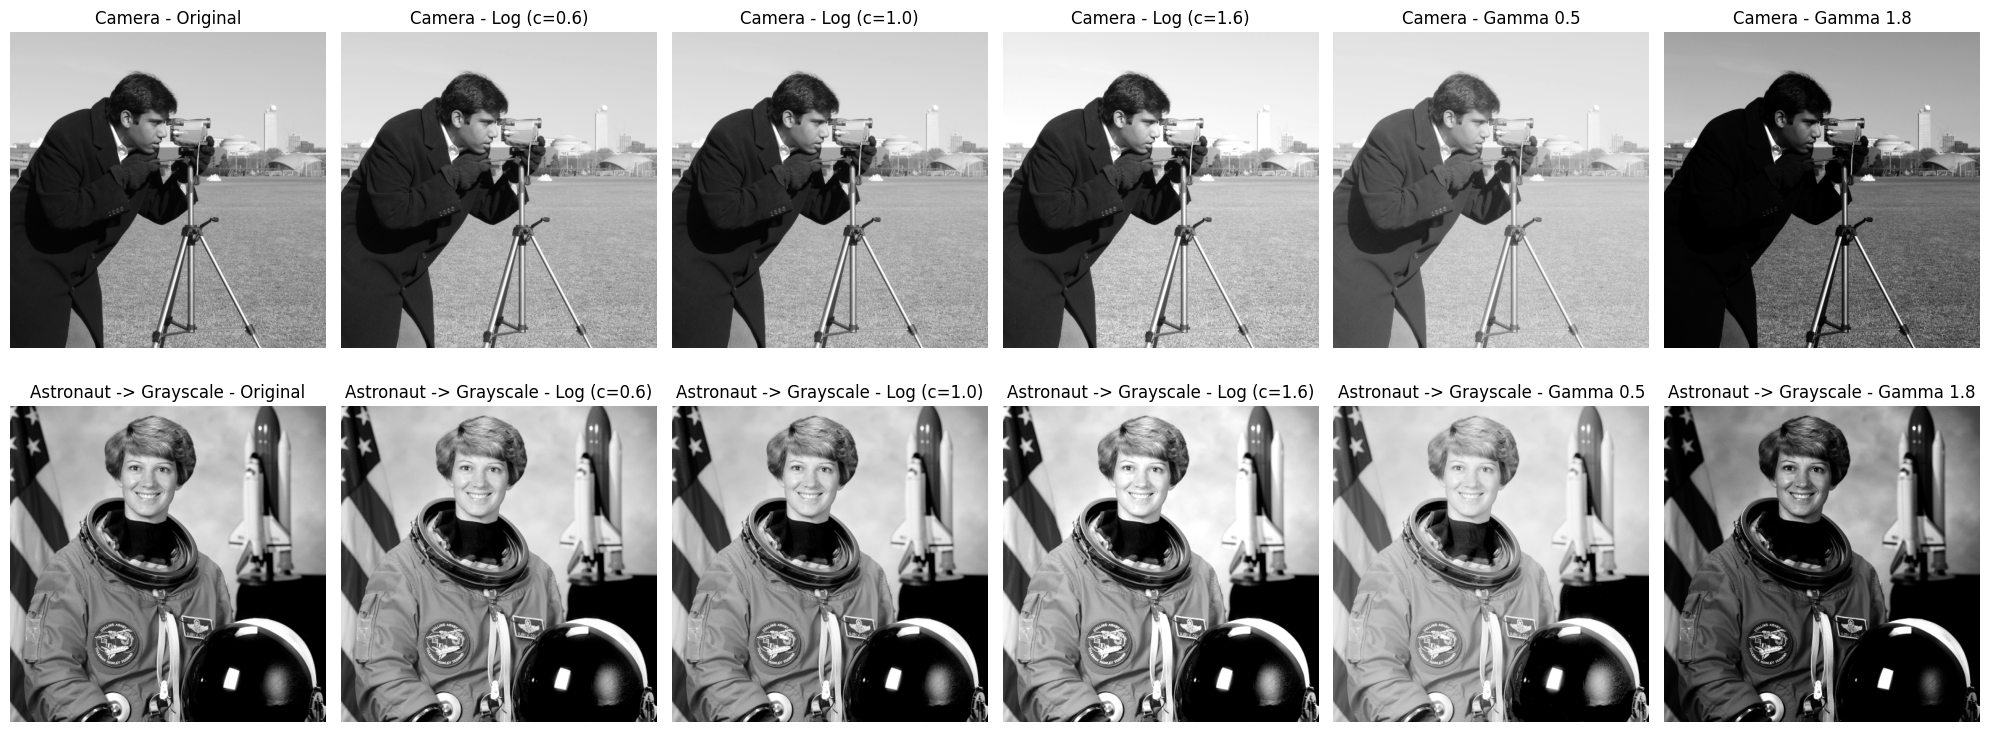

Analisis singkat:
- Camera:
  Log mean (c=0.6, 1.0, 1.6): 0.2336, 0.3894, 0.6222
  Gamma mean (g=0.5): 0.6660 -> lebih terang
  Gamma mean (g=1.8): 0.3647 -> lebih gelap
- Astronaut -> Grayscale:
  Log mean (c=0.6, 1.0, 1.6): 0.2062, 0.3437, 0.5479
  Gamma mean (g=0.5): 0.5921 -> lebih terang
  Gamma mean (g=1.8): 0.3062 -> lebih gelap
Kesimpulan: semakin besar c pada log, hasil cenderung makin terang; gamma<1 mencerahkan, gamma>1 menggelapkan.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# 1) Siapkan dua citra grayscale berbeda
img1 = img_as_float(data.camera())
img2 = color.rgb2gray(img_as_float(data.astronaut()))

# 2) Parameter transformasi
c_values = [0.6, 1.0, 1.6]
gamma_bright = 0.5  # mencerahkan
gamma_dark = 1.8    # menggelapkan

# 3) Fungsi transformasi logaritmik
# s = c * log(1 + r), lalu dipotong ke [0,1] agar efek c tetap terlihat
def log_transform(image, c_val=1.0):
    out = c_val * np.log1p(image)
    return np.clip(out, 0, 1)

# 4) Terapkan transformasi pada kedua citra
results = []
for img, name in [(img1, "Camera"), (img2, "Astronaut -> Grayscale")]:
    log_images = [log_transform(img, c) for c in c_values]
    gamma_low = exposure.adjust_gamma(img, gamma=gamma_bright)
    gamma_high = exposure.adjust_gamma(img, gamma=gamma_dark)
    results.append((name, img, log_images, gamma_low, gamma_high))

# 5) Visualisasi
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
for row, (name, original, log_images, g_low, g_high) in enumerate(results):
    axes[row, 0].imshow(original, cmap='gray')
    axes[row, 0].set_title(f"{name} - Original")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(log_images[0], cmap='gray')
    axes[row, 1].set_title(f"{name} - Log (c={c_values[0]})")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(log_images[1], cmap='gray')
    axes[row, 2].set_title(f"{name} - Log (c={c_values[1]})")
    axes[row, 2].axis('off')

    axes[row, 3].imshow(log_images[2], cmap='gray')
    axes[row, 3].set_title(f"{name} - Log (c={c_values[2]})")
    axes[row, 3].axis('off')

    axes[row, 4].imshow(g_low, cmap='gray')
    axes[row, 4].set_title(f"{name} - Gamma {gamma_bright}")
    axes[row, 4].axis('off')

    axes[row, 5].imshow(g_high, cmap='gray')
    axes[row, 5].set_title(f"{name} - Gamma {gamma_dark}")
    axes[row, 5].axis('off')

plt.tight_layout()
plt.show()

# 6) Ringkasan analisis numerik sederhana
print("Analisis singkat:")
for img, name in [(img1, "Camera"), (img2, "Astronaut -> Grayscale")]:
    log_means = [np.mean(log_transform(img, c)) for c in c_values]
    gamma_low_mean = np.mean(exposure.adjust_gamma(img, gamma=gamma_bright))
    gamma_high_mean = np.mean(exposure.adjust_gamma(img, gamma=gamma_dark))
    print(f"- {name}:")
    print(f"  Log mean (c={c_values[0]}, {c_values[1]}, {c_values[2]}): {log_means[0]:.4f}, {log_means[1]:.4f}, {log_means[2]:.4f}")
    print(f"  Gamma mean (g={gamma_bright}): {gamma_low_mean:.4f} -> lebih terang")
    print(f"  Gamma mean (g={gamma_dark}): {gamma_high_mean:.4f} -> lebih gelap")

print("Kesimpulan: semakin besar c pada log, hasil cenderung makin terang; gamma<1 mencerahkan, gamma>1 menggelapkan.")